In [1]:
import os
import sys
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import metric as mt
import matplotlib.ticker as ticker
from glob import glob

### Analysis

In [2]:
num_trials = 10
pop = 'EUR'
centers = ['BCM','BGI','BI','WUGSC']
props = ['0.01', '0.05', '0.10', '0.15', '0.20']
sim_ret_dfs = []

for prop in props:
    sim_dir = f'summary-sim-del2-{prop}-prior'
    print('='*50)
    for center in centers:    
        for i in range(num_trials):
            
            print(pop, prop, center, i)

            fp = f'../{sim_dir}/results-simulation-{i}/{pop}.{center}.concat.eval.bed'
            sim_ret_df = pd.read_csv(fp, sep='\t')
            
            sim_ret_df = sim_ret_df.loc[sim_ret_df.alpha_beta > 1000]
            sim_ret_dfs.append(sim_ret_df)

EUR 0.01 BCM 0
EUR 0.01 BCM 1
EUR 0.01 BCM 2
EUR 0.01 BCM 3
EUR 0.01 BCM 4
EUR 0.01 BCM 5
EUR 0.01 BCM 6
EUR 0.01 BCM 7
EUR 0.01 BCM 8
EUR 0.01 BCM 9
EUR 0.01 BGI 0
EUR 0.01 BGI 1
EUR 0.01 BGI 2
EUR 0.01 BGI 3
EUR 0.01 BGI 4
EUR 0.01 BGI 5
EUR 0.01 BGI 6
EUR 0.01 BGI 7
EUR 0.01 BGI 8
EUR 0.01 BGI 9
EUR 0.01 BI 0
EUR 0.01 BI 1
EUR 0.01 BI 2
EUR 0.01 BI 3
EUR 0.01 BI 4
EUR 0.01 BI 5
EUR 0.01 BI 6
EUR 0.01 BI 7
EUR 0.01 BI 8
EUR 0.01 BI 9
EUR 0.01 WUGSC 0
EUR 0.01 WUGSC 1
EUR 0.01 WUGSC 2
EUR 0.01 WUGSC 3
EUR 0.01 WUGSC 4
EUR 0.01 WUGSC 5
EUR 0.01 WUGSC 6
EUR 0.01 WUGSC 7
EUR 0.01 WUGSC 8
EUR 0.01 WUGSC 9
EUR 0.05 BCM 0
EUR 0.05 BCM 1
EUR 0.05 BCM 2
EUR 0.05 BCM 3
EUR 0.05 BCM 4
EUR 0.05 BCM 5
EUR 0.05 BCM 6
EUR 0.05 BCM 7
EUR 0.05 BCM 8
EUR 0.05 BCM 9
EUR 0.05 BGI 0
EUR 0.05 BGI 1
EUR 0.05 BGI 2
EUR 0.05 BGI 3
EUR 0.05 BGI 4
EUR 0.05 BGI 5
EUR 0.05 BGI 6
EUR 0.05 BGI 7
EUR 0.05 BGI 8
EUR 0.05 BGI 9
EUR 0.05 BI 0
EUR 0.05 BI 1
EUR 0.05 BI 2
EUR 0.05 BI 3
EUR 0.05 BI 4
EUR 0.05 BI 5
EUR 0.

In [3]:
%%time
all_cnv_samples = []

# the for loops look awful but runtime is not bad
for p in props:
    sim_dir = f'../summary-sim-del2-{p}-prior'
    for c in centers:
        for i in range(num_trials):
            for g in sim_ret_df.gene.unique():
                df_summ = pd.read_csv(f'{sim_dir}/results-simulation-{i}/sim.summary.{c}.{g}.{i}.txt', sep='\t')
                for s in df_summ['sample']:
                    all_cnv_samples.append(f'{p}-{c}-{i}-{g}-{s}')

# print(all_cnv_samples)
print(len(all_cnv_samples))

70370
CPU times: user 8.1 s, sys: 1.63 s, total: 9.73 s
Wall time: 2min 5s


In [4]:
%%time

dfs = []
num = 0
for k,p in enumerate(props):          # 5 props
    for j,c in enumerate(centers):    # 4 centers
        for i in range(num_trials):   # 10 trials

            df = sim_ret_dfs[num].copy()
            df['refcn'] = df.refcn.astype('Int32')
            df['code'] = df.apply(lambda r: f"{p}-{c}-{i}-{r.gene}-{r['name']}", axis=1)
            df['prop'] = p
            
            # ===============================================
            # Concordance
            
            # df[[
            #     'ref_acc', 'ref_err', 'ref_fil', 'ref_acc_f', 'ref_err_f',
            #     'nref_acc', 'nref_err', 'nref_fil', 'nref_acc_f', 'nref_err_f'
            # ]] = df.apply(lambda row: pd.Series(mt.v_correct3(row.hmm, row.truth, row.refcn)), axis=1)

            df[[
                'comb_acc', 'comb_err', 'comb_fil', 'comb_acc_f', 'comb_err_f',
            ]] = df.apply(lambda row: pd.Series(mt.v_correct_combined(row.hmm, row.truth, row.refcn)), axis=1)

            # ===============================================
            # TPFPFN

            df['tpfpfn'] = df.apply(lambda row: mt.v_tpfpfn(row.hmm, row.truth, row.refcn), axis=1)

            # ===============================================
            # Other

            df['num_exon'] = df.hmm.apply(lambda x: len(x.split(',')))
            df['num_samples'] = df['name'].unique().shape[0]

            print(f'{p} - {c} - {i}')
            
            dfs.append(df)
            num += 1

    
print('='*60)
print('ALL')

all_df = pd.concat(dfs, axis=0)
all_df = all_df.loc[all_df.code.isin(all_cnv_samples)].copy()


df_acc_all1 = pd.DataFrame(all_df.groupby(['prop','gene'])[['comb_acc_f','comb_fil']].mean()).reset_index()
df_acc_all2 = pd.DataFrame(all_df.groupby(['prop','gene'])[['tpfpfn']].sum()).reset_index()

0.01 - BCM - 0
0.01 - BCM - 1
0.01 - BCM - 2
0.01 - BCM - 3
0.01 - BCM - 4
0.01 - BCM - 5
0.01 - BCM - 6
0.01 - BCM - 7
0.01 - BCM - 8
0.01 - BCM - 9
0.01 - BGI - 0
0.01 - BGI - 1
0.01 - BGI - 2
0.01 - BGI - 3
0.01 - BGI - 4
0.01 - BGI - 5
0.01 - BGI - 6
0.01 - BGI - 7
0.01 - BGI - 8
0.01 - BGI - 9
0.01 - BI - 0
0.01 - BI - 1
0.01 - BI - 2
0.01 - BI - 3
0.01 - BI - 4
0.01 - BI - 5
0.01 - BI - 6
0.01 - BI - 7
0.01 - BI - 8
0.01 - BI - 9
0.01 - WUGSC - 0
0.01 - WUGSC - 1
0.01 - WUGSC - 2
0.01 - WUGSC - 3
0.01 - WUGSC - 4
0.01 - WUGSC - 5
0.01 - WUGSC - 6
0.01 - WUGSC - 7
0.01 - WUGSC - 8
0.01 - WUGSC - 9
0.05 - BCM - 0
0.05 - BCM - 1
0.05 - BCM - 2
0.05 - BCM - 3
0.05 - BCM - 4
0.05 - BCM - 5
0.05 - BCM - 6
0.05 - BCM - 7
0.05 - BCM - 8
0.05 - BCM - 9
0.05 - BGI - 0
0.05 - BGI - 1
0.05 - BGI - 2
0.05 - BGI - 3
0.05 - BGI - 4
0.05 - BGI - 5
0.05 - BGI - 6
0.05 - BGI - 7
0.05 - BGI - 8
0.05 - BGI - 9
0.05 - BI - 0
0.05 - BI - 1
0.05 - BI - 2
0.05 - BI - 3
0.05 - BI - 4
0.05 - BI - 5
0.05 -

In [5]:
df_acc_all1

,prop,gene,comb_acc_f,comb_fil
0,0.01,ACSM2A,1.0,0.000000
1,0.01,AKR1B10,1.0,0.000000
2,0.01,AKR7A3,1.0,0.000000
3,0.01,AQP12A,1.0,0.000000
4,0.01,BMP8A,1.0,0.007143
...,...,...,...,...
125,0.20,ROPN1,1.0,0.004188
126,0.20,THOC3,1.0,0.000519
127,0.20,TIMM23,1.0,0.000000
128,0.20,XCL1,1.0,0.000000


In [6]:
df_acc_all2['tp'] = df_acc_all2['tpfpfn'].apply(lambda l: l[0]+l[3])
df_acc_all2['fp'] = df_acc_all2['tpfpfn'].apply(lambda l: l[1]+l[4])
df_acc_all2['fn'] = df_acc_all2['tpfpfn'].apply(lambda l: l[2]+l[5])
df_acc_all2['total'] = df_acc_all2['tpfpfn'].apply(lambda l: sum(l))
df_acc_all2

,prop,gene,tpfpfn,tp,fp,fn,total
0,0.01,ACSM2A,"[0.0, 0.0, 0.0, 50.0, 0.0, 0.0, 5.0]",50.0,0.0,0.0,55.0
1,0.01,AKR1B10,"[0.0, 0.0, 0.0, 54.0, 0.0, 0.0, 2.0]",54.0,0.0,0.0,56.0
2,0.01,AKR7A3,"[0.0, 0.0, 0.0, 50.0, 0.0, 0.0, 4.0]",50.0,0.0,0.0,54.0
3,0.01,AQP12A,"[0.0, 0.0, 0.0, 53.0, 0.0, 0.0, 7.0]",53.0,0.0,0.0,60.0
4,0.01,BMP8A,"[0.0, 0.0, 0.0, 56.0, 0.0, 0.0, 1.0]",56.0,0.0,0.0,57.0
...,...,...,...,...,...,...,...
125,0.20,ROPN1,"[0.0, 0.0, 0.0, 951.0, 0.0, 0.0, 51.0]",951.0,0.0,0.0,1002.0
126,0.20,THOC3,"[0.0, 0.0, 0.0, 963.0, 0.0, 0.0, 34.0]",963.0,0.0,0.0,997.0
127,0.20,TIMM23,"[0.0, 0.0, 0.0, 955.0, 0.0, 0.0, 42.0]",955.0,0.0,0.0,997.0
128,0.20,XCL1,"[0.0, 0.0, 0.0, 966.0, 0.0, 0.0, 44.0]",966.0,0.0,0.0,1010.0


In [7]:
df_acc_all = df_acc_all1.merge(df_acc_all2, on=['prop','gene'], how='left')
df_acc_all = df_acc_all.drop(columns=['tpfpfn'])
df_acc_all

,prop,gene,comb_acc_f,comb_fil,tp,fp,fn,total
0,0.01,ACSM2A,1.0,0.000000,50.0,0.0,0.0,55.0
1,0.01,AKR1B10,1.0,0.000000,54.0,0.0,0.0,56.0
2,0.01,AKR7A3,1.0,0.000000,50.0,0.0,0.0,54.0
3,0.01,AQP12A,1.0,0.000000,53.0,0.0,0.0,60.0
4,0.01,BMP8A,1.0,0.007143,56.0,0.0,0.0,57.0
...,...,...,...,...,...,...,...,...
125,0.20,ROPN1,1.0,0.004188,951.0,0.0,0.0,1002.0
126,0.20,THOC3,1.0,0.000519,963.0,0.0,0.0,997.0
127,0.20,TIMM23,1.0,0.000000,955.0,0.0,0.0,997.0
128,0.20,XCL1,1.0,0.000000,966.0,0.0,0.0,1010.0


In [8]:
meta = []
for p in props:
    sim_dir = f'../summary-sim-del2-{p}-prior'
    for c in centers[:1]:
        for i in range(1):
            for g in sim_ret_dfs[0].gene.unique():
                df_summ = pd.read_csv(f'{sim_dir}/results-simulation-{i}/sim.summary.{c}.{g}.{i}.txt', sep='\t')
                df_summ['gene'] = g
                df_summ['center'] = c
                df_summ['prop'] = p
                to_add = df_summ.iloc[0,:][['prop','gene','num_exons','mode']]
                meta.append(to_add)
                
meta_df = pd.DataFrame(meta)
final_df = meta_df.merge(df_acc_all, on=['prop','gene'], how='left')

exclude = ['LGALS7', 'OBP2A']
final_df = final_df.loc[~final_df.gene.isin(exclude)]

final_df['prec'] = final_df['tp']/(final_df['tp']+final_df['fp'])
final_df['reca'] = final_df['tp']/(final_df['tp']+final_df['fn'])
final_df

,prop,gene,num_exons,mode,comb_acc_f,comb_fil,tp,fp,fn,total,prec,reca
0,0.01,CFC1,all 6/6,"0.01,deletion,0.5",1.0,0.000000,54.0,0.0,0.0,55.0,1.0,1.0
1,0.01,BMP8A,all 5/5,"0.01,deletion,0.5",1.0,0.007143,56.0,0.0,0.0,57.0,1.0,1.0
2,0.01,XCL1,all 3/3,"0.01,deletion,0.5",1.0,0.000000,55.0,0.0,0.0,57.0,1.0,1.0
3,0.01,ROPN1,all 3/3,"0.01,deletion,0.5",1.0,0.018182,54.0,0.0,0.0,57.0,1.0,1.0
4,0.01,PDZK1,all 7/7,"0.01,deletion,0.5",1.0,0.000000,56.0,0.0,0.0,58.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
124,0.20,CD8B,all 5/5,"0.2,deletion,0.5",1.0,0.001049,952.0,0.0,0.0,999.0,1.0,1.0
125,0.20,CYP11B1,all 6/6,"0.2,deletion,0.5",1.0,0.000000,945.0,0.0,0.0,996.0,1.0,1.0
126,0.20,GPR89A,all 14/14,"0.2,deletion,0.5",1.0,0.000148,968.0,0.0,0.0,1010.0,1.0,1.0
127,0.20,ACSM2A,all 12/12,"0.2,deletion,0.5",1.0,0.000000,966.0,0.0,0.0,1006.0,1.0,1.0


In [9]:
def bin_num_exon(exons):
    if exons < 5:
        return 'x<5'
    if exons < 10:
        return '5<=x<10'
    else:
        return '10<=x'
    
final_df['exons'] = final_df['num_exons'].apply(lambda x: int(x.split(' ')[1].split('/')[1]))
final_df['exon_bin'] = final_df['exons'].apply(lambda x: bin_num_exon(x))
final_df

,prop,gene,num_exons,mode,comb_acc_f,comb_fil,tp,fp,fn,total,prec,reca,exons,exon_bin
0,0.01,CFC1,all 6/6,"0.01,deletion,0.5",1.0,0.000000,54.0,0.0,0.0,55.0,1.0,1.0,6,5<=x<10
1,0.01,BMP8A,all 5/5,"0.01,deletion,0.5",1.0,0.007143,56.0,0.0,0.0,57.0,1.0,1.0,5,5<=x<10
2,0.01,XCL1,all 3/3,"0.01,deletion,0.5",1.0,0.000000,55.0,0.0,0.0,57.0,1.0,1.0,3,x<5
3,0.01,ROPN1,all 3/3,"0.01,deletion,0.5",1.0,0.018182,54.0,0.0,0.0,57.0,1.0,1.0,3,x<5
4,0.01,PDZK1,all 7/7,"0.01,deletion,0.5",1.0,0.000000,56.0,0.0,0.0,58.0,1.0,1.0,7,5<=x<10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,0.20,CD8B,all 5/5,"0.2,deletion,0.5",1.0,0.001049,952.0,0.0,0.0,999.0,1.0,1.0,5,5<=x<10
125,0.20,CYP11B1,all 6/6,"0.2,deletion,0.5",1.0,0.000000,945.0,0.0,0.0,996.0,1.0,1.0,6,5<=x<10
126,0.20,GPR89A,all 14/14,"0.2,deletion,0.5",1.0,0.000148,968.0,0.0,0.0,1010.0,1.0,1.0,14,10<=x
127,0.20,ACSM2A,all 12/12,"0.2,deletion,0.5",1.0,0.000000,966.0,0.0,0.0,1006.0,1.0,1.0,12,10<=x


In [10]:
final_df.exon_bin.value_counts()

exon_bin
5<=x<10    45
x<5        45
10<=x      30
Name: count, dtype: int64

### Visualization

In [11]:
final_df2 = final_df.groupby('prop')[['comb_acc_f','comb_fil','prec','reca']].mean().reset_index()
final_df2

,prop,comb_acc_f,comb_fil,prec,reca
0,0.01,1.000000,0.001813,1.000000,1.000000
1,0.05,0.999632,0.000657,0.999660,0.999971
2,0.10,0.999827,0.000643,0.999827,1.000000
3,0.15,0.999808,0.001131,0.999827,0.999981
4,0.20,0.999694,0.000866,0.999825,0.999869


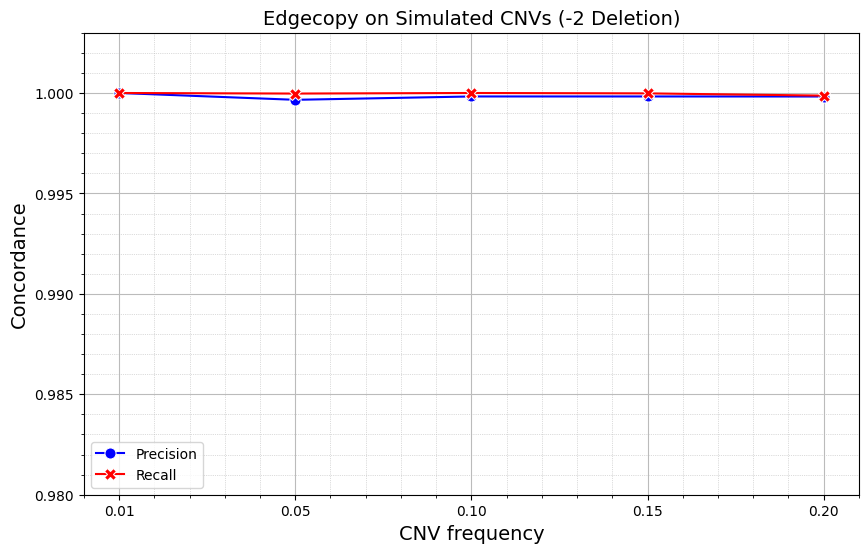

In [12]:
plt.figure(figsize=(10, 6))

ax = sns.lineplot(final_df2, x='prop', y='prec', color='blue',
                  marker='o', markersize=8, label='Precision')

sns.lineplot(final_df2, x='prop', y='reca', color='red',
                  marker='X', markersize=8, label='Recall')

# Formatting
ax.grid(which='major', color='#BBBBBB', linewidth=0.8)
ax.grid(which='minor', color='#BBBBBB', linestyle=':', linewidth=0.5)
ax.minorticks_on()
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

plt.legend(loc='lower left')
plt.title('Edgecopy on Simulated CNVs (-2 Deletion)', fontsize=14)
plt.xlabel('CNV frequency', fontsize=14)
plt.ylabel('Concordance', fontsize=14)
plt.ylim(0.98, 1.003)
plt.show()

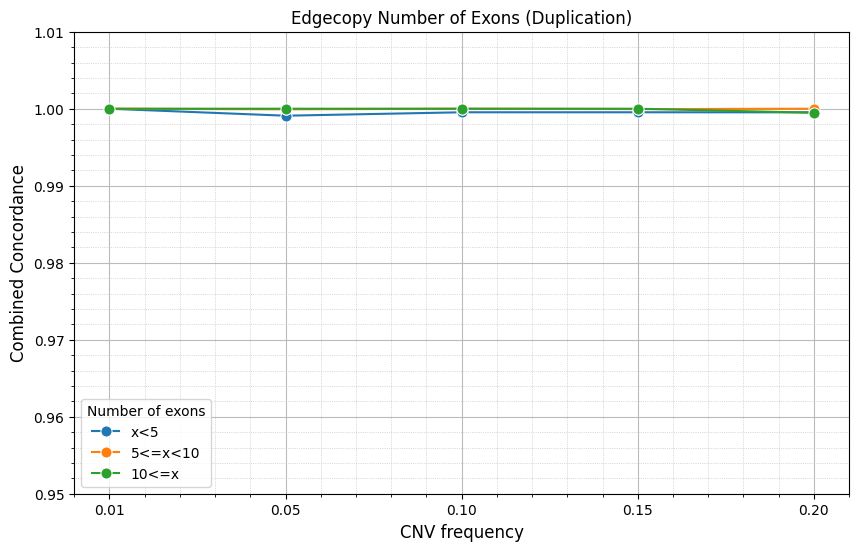

In [13]:
plt.figure(figsize=(10, 6))

ax = sns.lineplot(final_df, x='prop', y='comb_acc_f', 
                  hue='exon_bin', 
                  hue_order=['x<5', '5<=x<10', '10<=x'],
                  errorbar=None, 
                  marker='o',
                  markersize=8)

# Formatting
ax.grid(which='major', color='#BBBBBB', linewidth=0.8)
ax.grid(which='minor', color='#BBBBBB', linestyle=':', linewidth=0.5)
ax.minorticks_on()
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

plt.legend(title='Number of exons', loc='lower left')
plt.title('Edgecopy Number of Exons (Duplication)')
plt.xlabel('CNV frequency', fontsize=12)
plt.ylabel('Combined Concordance', fontsize=12)
plt.ylim(0.95, 1.01)
plt.show()